<a href="https://colab.research.google.com/github/CharalapML/ColabCode/blob/main/Galileo's_Wave_Interactive_Pendulum_A02_y_dimension_small_angle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Based on work on youtube by Mr P. Solver**




Position  on 1D path

Parabola :   $x =(\theta)$ and $y= \theta$

Simple Pendulum: $x = lsin(\theta)$ and $y = -lcos(\theta)$, where $l$ = length of pendulum

Kinetic energy:  $T = \frac{1}{2}m ({\dot x}^2 + {\dot y}^2)$ , where $\large\dot x = \frac{dx}{dt}  $  and $\large\dot y = \frac{dy}{dt}  $

Potential Energy: $V = mgy$

The Lagrangian: $L ({d\theta},{d\dot \theta}, {t)}  = T - V$

Lagranges Eqn:  $\large\frac{dL}{d\theta} - \frac{d}{dt}\frac{dL}{d\dot \theta} = 0$ , where $\large\dot\theta = \frac{d\theta}{dt}  $

So

$\large\frac{dL}{d\theta} = \frac{d}{dt}\frac{dL}{d\dot \theta} $     $i.e.   \large lhs = rhs $

In [1]:
pip install ipyvolume

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.7/260.7 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.7/271.7 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 50.5 MB/s eta 0:00:00


In [2]:
import numpy as np
import sympy as sp
from sympy.utilities import lambdify
from sympy.solvers import solve
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib import animation
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import PillowWriter
from IPython.display import HTML

import mpl_toolkits.mplot3d.axes3d as p3
import ipyvolume as ipv

In [3]:
class Pendulum:
  def __init__(self, l, t, theta0, v0):  #theta0 = starting angle, v0 = starting velocity
    self.l = l
    self.t = t
    self.conds = [theta0, v0]

  def SolvePendulum(self):
    # m = mass, g = gravity (=9.81m/s), l = length of pendulum, t = time
    m,g,l,t = sp.symbols('m g l t')
    theta = sp.Function('theta')(t)
    #display(theta)
    dtheta  = theta.diff(t)   # velocity
    ddtheta = dtheta.diff(t)  # acceleration

    x,y = l*sp.sin(theta), -l*sp.cos(theta)

    T = sp.Rational(1,2) * m * (x.diff(t)**2 + y.diff(t)**2)
    V = m*g*y
    L = T-V

    display(L.simplify())

    lhs = L.diff(theta)
    rhs = sp.diff(L.diff(dtheta), t)

    eq = rhs - lhs
    #display(eq)
    eq = sp.solve(eq, ddtheta)[0]
    display(eq.simplify())

    dthetadt_num =sp.lambdify(dtheta, dtheta)
    dudt_num  = sp.lambdify((g, l, theta), eq)

    x_num, y_num = sp.lambdify((l, theta), x), sp.lambdify((l,theta), y)
    # x_num, y_num are 𝑙𝑠𝑖𝑛(𝜃) and 𝑦= -𝑙𝑐𝑜𝑠(𝜃)

    del m,g,l,t

    g = 9.81
    l = self.l
    t = self.t
    conds =self.conds

    def dXdt(X,t,g,l):
      theta_num, u_num = X

      return [dthetadt_num(u_num),
              dudt_num(g,l,theta_num)]

    sol = odeint(dXdt, t=t, y0=conds, args=(g,l))
    angle = sol.T[0] # ie theta
    velocity = sol.T[1]

    return x_num(l,angle), y_num(l,angle), sol  # sol.T,


# **Need a for loop in next cell**

In [4]:
t = np.linspace(0,100,5000)

# length = [1.0, 1.38268, 1.70711, 1.92388, 2.0, 1.92388, 1.70711, 1.38268, 1.0, 1.38268, 1.70711, 1.92388, 2.0, 1.92388, 1.70711, 1.38268]
length = [0.248490203, 0.265922928, 0.28525661, 0.306778028, 0.330830152, 0.357825892, 0.388265942, 0.42276216, 0.462068559, 0.507122863, 0.559102956, 0.619504661, 0.690250564, 0.773844922, 0.87359837, 0.993960812]
pendlist =['pend', 'pend1', 'pend2', 'pend3', 'pend4', 'pend5', 'pend6', 'pend7', 'pend8', 'pend9', 'pend10', 'pend11', 'pend12', 'pend13', 'pend14', 'pend15']
# Ypoint = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0]

xlist = ['x', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11', 'x12', 'x13', 'x14', 'x15']
zlist = ['z', 'z1', 'z2', 'z3', 'z4', 'z5', 'z6', 'z7', 'z8', 'z9', 'z10', 'z11', 'z12', 'z13', 'z14', 'z15']
sollist = ['sol', 'sol1', 'sol2', 'sol3','sol4', 'sol5', 'sol6', 'sol7', 'sol8', 'sol9', 'sol10', 'sol11','sol12', 'sol13', 'sol14', 'sol15']

xa = []
za = []
sola = []

for p, l, x, y, sol in zip (pendlist, length, xlist, zlist, sollist):
  p = Pendulum(l, t, np.pi/6, 0)
  x,z,sol = p.SolvePendulum()
  xa.append(x)
  za.append(z)
  sola.append(sol)

# pend = Pendulum(1, t, np.pi/2, 0)
# #pend.SolvePendulum()
# #sol = pend.SolvePendulum()
# x,y,sol = pend.SolvePendulum()

# pend1 = Pendulum(0.5, t, -np.pi/2, 0)
# #pend.SolvePendulum()
# #sol = pend.SolvePendulum()
# x1,y1,sol1 = pend1.SolvePendulum()

l*m*(2*g*cos(theta(t)) + l*Derivative(theta(t), t)**2)/2

-g*sin(theta(t))/l

l*m*(2*g*cos(theta(t)) + l*Derivative(theta(t), t)**2)/2

-g*sin(theta(t))/l

l*m*(2*g*cos(theta(t)) + l*Derivative(theta(t), t)**2)/2

...

-g*sin(theta(t))/l

l*m*(2*g*cos(theta(t)) + l*Derivative(theta(t), t)**2)/2

-g*sin(theta(t))/l

l*m*(2*g*cos(theta(t)) + l*Derivative(theta(t), t)**2)/2

-g*sin(theta(t))/l

The period T of a pendulum with a cord length L is given by the formula T = 2π√(L/g)

2, π and g constants so the determining variable is √(L)


In [5]:
# Create a sequence of numbers from A to B (inclusive) with a step of 1
A = 5
B = 15
sequence = np.arange(A, B+1, 1)  # NB  -1 if sequence goes from high to low

# Reverse the sequence and exclude the last (highest or lowest number)
reversed_sequence = sequence[-2::-1]

# Concatenate the two sequences
Seq = np.hstack((sequence, reversed_sequence))#.shape

sequence
reversed_sequence
Seq
lenseq =len(Seq)
lenseq

21

In [6]:
Seq[20]

np.int64(5)

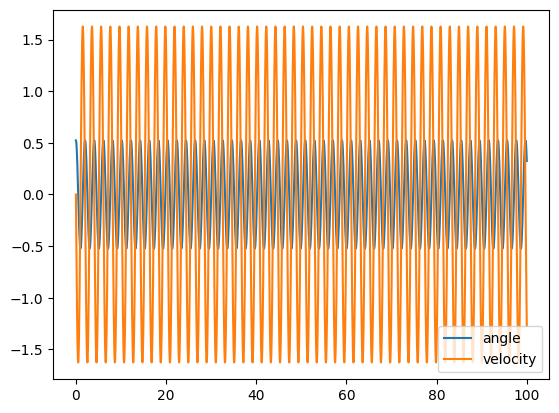

In [7]:
theta = sol.T[0]
velocity = sol.T[1]

plt.plot(t, theta, label ='angle')
plt.plot(t, velocity, label = 'velocity')
plt.legend()

In [8]:
# plt.plot(t,x1)

In [9]:
for l in range (Seq[0],Seq[lenseq-1]):
  t = np.linspace(0,10,500)


# **Need for loop for the next cell**

-0.21519882838955215 1.0 [-0.86079531 -0.86128545 -0.86274916 ... -0.92604911 -0.93426998
 -0.94240266]
-0.23029601109674022 2.0 [-0.86079531 -0.86128545 -0.86274916 ... -0.92604911 -0.93426998
 -0.94240266]
-0.24703947085743017 3.0 [-0.86079531 -0.86128545 -0.86274916 ... -0.92604911 -0.93426998
 -0.94240266]
-0.26567756557089384 4.0 [-0.86079531 -0.86128545 -0.86274916 ... -0.92604911 -0.93426998
 -0.94240266]
-0.2865073159698672 5.0 [-0.86079531 -0.86128545 -0.86274916 ... -0.92604911 -0.93426998
 -0.94240266]
-0.30988631260382693 6.0 [-0.86079531 -0.86128545 -0.86274916 ... -0.92604911 -0.93426998
 -0.94240266]
-0.33624816919629547 7.0 [-0.86079531 -0.86128545 -0.86274916 ... -0.92604911 -0.93426998
 -0.94240266]
-0.3661227703187815 8.0 [-0.86079531 -0.86128545 -0.86274916 ... -0.92604911 -0.93426998
 -0.94240266]
-0.4001631103840687 9.0 [-0.86079531 -0.86128545 -0.86274916 ... -0.92604911 -0.93426998
 -0.94240266]
-0.4391812821978956 10.0 [-0.86079531 -0.86128545 -0.86274916 ... -

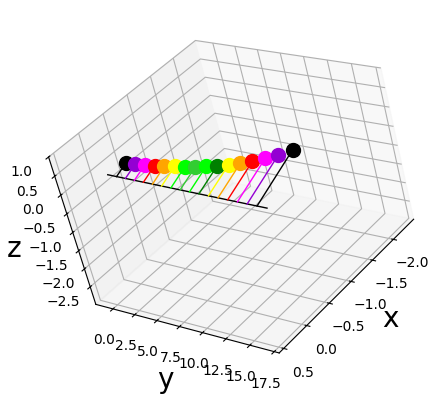

In [10]:
#  FLIP X and Z  axes

# x0list = [xa[0][0], xa[1][0], xa[2][0], xa[3][0], xa[4][0], xa[5][0], xa[6][0], xa[7][0], xa[8][0], xa[9][0], xa[10][0], xa[11][0], xa[12][0], xa[13][0], xa[14][0], xa[15][0] ]
# z0list = [za[0][0], za[1][0], za[2][0], za[3][0], za[4][0], za[5][0], za[6][0], za[7][0], za[8][0], za[9][0], za[10][0], za[11][0], za[12][0], za[13][0], za[14][0], za[15][0] ]

z0list = [xa[0][0], xa[1][0], xa[2][0], xa[3][0], xa[4][0], xa[5][0], xa[6][0], xa[7][0], xa[8][0], xa[9][0], xa[10][0], xa[11][0], xa[12][0], xa[13][0], xa[14][0], xa[15][0] ]
x0list = [za[0][0], za[1][0], za[2][0], za[3][0], za[4][0], za[5][0], za[6][0], za[7][0], za[8][0], za[9][0], za[10][0], za[11][0], za[12][0], za[13][0], za[14][0], za[15][0] ]


Ypoint = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0]

colours  = ['black', 'darkviolet', 'magenta', 'red', 'orange', 'yellow', 'lime', 'limegreen', 'lime', 'green', 'yellow', 'orange', 'red', 'magenta', 'darkviolet', 'black' ]

# Store Line2D and Circle objects in
lines = []
bobs = []
bobradius = 0.05

import matplotlib as mpl
mpl.rcParams['axes3d.mouserotationstyle'] = 'azel' # 'trackball', 'trackball', 'sphere', or 'arcball'


fig = plt.figure()
ax = fig.add_subplot(projection = '3d')
ax.view_init(elev=30, azim=45, roll=15)

ax.set_xlabel('x', fontsize=20)
ax.set_ylabel('y', fontsize=20)
ax.set_zlabel('z', fontsize=20)

line0, = ax.plot([0,0],[0,17], [0,0], lw = 1, c = 'black')

for x0, z0, y0, col in zip(x0list, z0list, Ypoint, colours):
  line, = ax.plot([0,x0],[y0,y0], [0,z0], lw = 1, c = col)
  line.set_3d_properties([0,z0])
  lines.append(line)

  bob, = ax.plot([x0], [y0], [z0], 'o', color=col, markersize=10)
  bob.set_3d_properties([z0])
  bobs.append(bob)

  ax.set_xlim(-x.max()-2.0,x.max()+0.1)
  ax.set_ylim(-2.0,18.0)
  ax.set_zlim(z.min()-2.0, 1.0)

  print(x0,y0,z)
  #print(ll)

def animate(i):
  for ll, cl, zaa, xaa, yaa in zip(lines, bobs, za, xa, Ypoint):
    ll.set_data_3d([0,zaa[i]],[yaa,yaa], [0,xaa[i]])
    cl.set_data_3d([zaa[i]], [yaa], [xaa[i]])

steps = len(x)
frames = steps
dt = t[1] - t[0]
interval = dt*10000
# ani = animation.FuncAnimation(fig, animate, frames = steps, interval = interval, repeat = True)
# ani.save('pen.gif', writer = 'pillow', fps = 50)

ani = animation.FuncAnimation(fig, animate, frames = steps, interval = interval, repeat = True) # frames = 100*len(t))
ffmpeg_writer = animation.FFMpegWriter(fps=50)
ani.save('Pendulum1.mp4', writer = ffmpeg_writer)

In [11]:
STOP

NameError: name 'STOP' is not defined